# 🤖 AI News Analysis — DeepSeek v4

**Date:** 2026-07-20  
**Model:** `deepseek-v4-pro` via OpenAI-compatible API at `api.deepseek.com`  
**Database:** `../news_fetcher/news.db` (populated by `fetch_news.py`)  
**API Key:** loaded from `.env` in this folder

This notebook uses the DeepSeek API to analyze headlines collected by `fetch_news.py`, generating:

- 📝 **One-sentence AI summaries** of each article
- 🎭 **Sentiment labels** (positive / negative / neutral / mixed)
- 🏷️ **Topic tags** for categorization

---

### 🗄️ AI Columns Added to Schema

`analyze_news.py` (and this notebook) add four columns to the `articles` table:

| Column | Type | Purpose |
|---|---|---|
| `ai_summary` | TEXT | One-sentence AI-generated summary |
| `ai_sentiment` | TEXT | "positive", "negative", "neutral", or "mixed" |
| `ai_topics` | TEXT | Comma-separated topic tags (e.g. "politics, economy") |
| `ai_analyzed_at` | TEXT | UTC timestamp of when the AI analysis ran |

Articles with `ai_analyzed_at IS NULL` are pending analysis.

---

### 🔑 DeepSeek API Setup

The `.env` file in this folder contains:
```
DEEPSEEK_API_KEY=sk-...
```

Endpoint: `https://api.deepseek.com/chat/completions`  
SDK: Standard `openai` Python package (DeepSeek is OpenAI-compatible)  
Model: `deepseek-v4-pro` (or `deepseek-v4-flash` for faster/cheaper)

---
## 🔌 Cell 1: Connect to Database & Load API Key

Loads the `DEEPSEEK_API_KEY` from `.env` (in this folder), initializes the OpenAI-compatible DeepSeek client at `api.deepseek.com`, connects to the shared `../news_fetcher/news.db` database, and ensures the AI analysis columns (`ai_summary`, `ai_sentiment`, `ai_topics`, `ai_analyzed_at`) exist in the schema.

Prints a health summary: total articles, how many have been AI-analyzed, and how many are still pending. Run this first before any other cell.

In [15]:
# Cell 1: Setup — Load API key, connect DB, init AI columns
import os, sys, sqlite3, json, time, logging
from datetime import datetime, timezone
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

# Paths
HERE = Path(".").resolve()
ENV = HERE / ".env"
DB_PATH = HERE.parent / "news_fetcher" / "news.db"

load_dotenv(ENV)
api_key = os.getenv("DEEPSEEK_API_KEY")
if not api_key:
    raise RuntimeError("❌ DEEPSEEK_API_KEY not found. Check .env file in this folder.")

client = OpenAI(api_key=api_key, base_url="https://api.deepseek.com")
MODEL = "deepseek-v4-pro"

# Connect to the shared news database
conn = sqlite3.connect(str(DB_PATH))
conn.row_factory = sqlite3.Row

# Ensure AI columns exist
for col, typ in [("ai_summary","TEXT"),("ai_sentiment","TEXT"),("ai_topics","TEXT"),("ai_analyzed_at","TEXT")]:
    try: conn.execute(f"ALTER TABLE articles ADD COLUMN {col} {typ}")
    except sqlite3.OperationalError: pass
conn.commit()

# Quick health check
total = conn.execute("SELECT COUNT(*) FROM articles").fetchone()[0]
analyzed = conn.execute("SELECT COUNT(*) FROM articles WHERE ai_analyzed_at IS NOT NULL").fetchone()[0]
print(f"✅ Connected — {total:,} articles total, {analyzed:,} AI-analyzed, {total-analyzed:,} pending")
print(f"🤖 Model: {MODEL}")
print(f"🔑 API Key: {api_key[:10]}...{api_key[-4:]}")
print(f"🗄️  DB: {DB_PATH.resolve()}")

✅ Connected — 157 articles total, 118 AI-analyzed, 39 pending
🤖 Model: deepseek-v4-pro
🔑 API Key: sk-007ed02...32aa
🗄️  DB: D:\Deepin\Programming\20260719 OpenGovernment\news_fetcher\news.db


---
## 🤖 Cell 2: Define the `analyze_articles()` Function

Defines the core analysis pipeline: takes a list of article rows (from the DB), builds a prompt listing them all with source, title, and snippet, then sends it to DeepSeek with `response_format={"type": "json_object"}` to get structured output.

Returns a list of dicts with `ai_summary` (one sentence), `ai_sentiment` (positive/negative/neutral/mixed), and `ai_topics` (comma-separated tags). Results are saved directly to the DB via `UPDATE`.

The system prompt instructs DeepSeek to return ONLY valid JSON — no preamble, no markdown fences.

In [16]:
# Cell 2: Analyze a Single Batch with DeepSeek
# Sends the selected articles to DeepSeek, parses the JSON response, and stores results.

SYSTEM_PROMPT = """You are a professional news analyst. For each news article, return a JSON object with exactly these three fields:
- "summary": A one-sentence summary in plain English.
- "sentiment": One of "positive", "negative", "neutral", or "mixed".
- "topics": A comma-separated list of 1-3 relevant topic tags.

Return ONLY valid JSON, nothing else."""

def analyze_articles(article_rows, verbose=True):
    """Analyze a list of sqlite3.Row articles via DeepSeek. Returns list of dicts."""
    # Build prompt
    lines = []
    for i, row in enumerate(article_rows, 1):
        text = f"[{i}] [{row['source'].upper()}] {row['title']}"
        snippet = row["snippet"] if row["snippet"] else ""
        content = row["content"] if row["content"] else ""
        if snippet:
            text += f"\n    {snippet[:300]}"
        elif content and len(content) > 100:
            text += f"\n    {content[:500]}"
        lines.append(text)

    prompt = f"Analyze each of the following {len(article_rows)} news articles. Return a JSON array with one object per article, in the same order:\n\n" + "\n\n".join(lines)

    if verbose:
        print(f"📤 Sending {len(article_rows)} articles to DeepSeek…")

    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ],
        temperature=0.3,
        max_tokens=2048,
        response_format={"type": "json_object"},
    )
    content = resp.choices[0].message.content
    result = json.loads(content)

    # Normalize response format
    if isinstance(result, dict) and "articles" in result:
        result = result["articles"]
    if not isinstance(result, list):
        result = [result]

    # Merge back
    analyzed = []
    for i, row in enumerate(article_rows):
        entry = result[i] if i < len(result) else {}
        analyzed.append({
            "id": row["id"],
            "source": row["source"],
            "title": row["title"],
            "ai_summary": entry.get("summary", "")[:500],
            "ai_sentiment": entry.get("sentiment", "neutral")[:20],
            "ai_topics": entry.get("topics", "")[:200],
        })

    # Save to DB
    now = datetime.now(timezone.utc).isoformat()
    for a in analyzed:
        conn.execute(
            "UPDATE articles SET ai_summary=?, ai_sentiment=?, ai_topics=?, ai_analyzed_at=? WHERE id=?",
            (a["ai_summary"], a["ai_sentiment"], a["ai_topics"], now, a["id"]),
        )
    conn.commit()

    if verbose:
        for a in analyzed:
            print(f"  ✓ [{a['source'].upper()}] {a['ai_summary'][:80]}…  [{a['ai_sentiment']}]")

    return analyzed

print("✓ analyze_articles() ready.")
print("  SYSTEM_PROMPT configured for JSON output with summary/sentiment/topics")

✓ analyze_articles() ready.
  SYSTEM_PROMPT configured for JSON output with summary/sentiment/topics


---
## 🔥 Cell 3: Run AI Analysis on Pending Articles

Fetches the most recent pending articles (where `ai_analyzed_at IS NULL`) and sends them to the `analyze_articles()` function defined in Cell 2. Each call costs a few cents depending on model and batch size.

**Adjust `SAMPLE_SIZE`** to control how many articles to analyze in one notebook session. After running, it prints:

- A sentiment breakdown with visual bars (█)
- The top 10 topic tags being assigned by AI
- Total number of articles now analyzed in the database

> ℹ️ The background `live_ai_analyzer.py` script does this exact same thing continuously — run it in a terminal if you want hands-off analysis.

In [17]:
# Cell 3: 🔥 Run AI Analysis on a Sample (10 pending articles)
#
# Each call costs ~$0.001–$0.01 depending on model. Adjust BATCH_SIZE or sample size.
# Change `limit` to control how many you analyze in this run.

SAMPLE_SIZE = 10  # <-- how many articles to analyze

# Fetch pending articles
pending = conn.execute(
    "SELECT id, source, title, url, snippet, content FROM articles "
    "WHERE ai_analyzed_at IS NULL ORDER BY first_seen_at DESC LIMIT ?",
    (SAMPLE_SIZE,)
).fetchall()

if not pending:
    print("✅ All articles already analyzed! Nothing to do.")
else:
    print(f"📋 {len(pending)} articles pending. Starting analysis…\n")
    results = analyze_articles(pending)

    # Summary
    sentiments = {}
    all_topics = []
    for r in results:
        sentiments[r["ai_sentiment"]] = sentiments.get(r["ai_sentiment"], 0) + 1
        if r["ai_topics"]:
            all_topics.extend(t.strip() for t in r["ai_topics"].split(","))

    print(f"\n📊 Sentiment breakdown:")
    for s, c in sorted(sentiments.items(), key=lambda x: -x[1]):
        bar = "█" * c
        print(f"  {s:10s}: {bar} ({c})")

    if all_topics:
        from collections import Counter
        top_topics = Counter(all_topics).most_common(10)
        print(f"\n🏷️  Top topics:")
        for topic, count in top_topics:
            print(f"  {topic:20s}: {'█' * min(count, 20)} ({count})")

    total_done = conn.execute("SELECT COUNT(*) FROM articles WHERE ai_analyzed_at IS NOT NULL").fetchone()[0]
    print(f"\n✅ {total_done} articles now have AI analysis.")

📋 10 articles pending. Starting analysis…

📤 Sending 10 articles to DeepSeek…
  ✓ [BBC] The World Cup closing ceremony begins with a vibrant performance by IShowSpeed, …  [positive]
  ✓ [BBC] Ryan Fox wins his first major at the 2026 Open Championship with an impressive f…  [positive]
  ✓ [CNN] A lawyer publicly accuses the ICC chief prosecutor of sexual misconduct, which h…  [negative]
  ✓ [CNN] A swim team member drowns, two teens are charged with evidence tampering, and th…  [negative]
  ✓ [CNN] A tourist helicopter crashed into the Hudson River after hitting a flock of bird…  [negative]
  ✓ [CNN] Rubio and Miller warn 67 countries about the threat of far-left terrorism.…  [negative]
  ✓ [CNN] Trump's teleprompter operator is under investigation for insider trading.…  [neutral]
  ✓ [CNN] Truth Social plans to sell faster access to posts to Wall Street.…  [neutral]
  ✓ [CNN] Officials debated declassifying documents as Trump's campaign allegedly undermin…  [negative]
  ✓ [CNN] Speake

---
## 📊 Cell 4: View AI Analysis Results

Displays the most recent 20 articles that have been AI-analyzed as a pandas DataFrame. Each row shows the source, original title, AI-generated one-sentence summary, sentiment label, topic tags, and when the analysis ran.

Use this to spot-check the quality of the AI output — does the summary match the title? Are the topics reasonable?

In [18]:
# Cell 4: 📊 View AI Analysis Results — Latest Analyzed Articles
import pandas as pd

df_ai = pd.read_sql_query(
    "SELECT source, title, ai_summary, ai_sentiment, ai_topics, ai_analyzed_at "
    "FROM articles WHERE ai_analyzed_at IS NOT NULL "
    "ORDER BY ai_analyzed_at DESC LIMIT 20",
    conn
)
df_ai["ai_analyzed_at"] = pd.to_datetime(df_ai["ai_analyzed_at"])
df_ai.index = range(1, len(df_ai) + 1)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 250)
print(df_ai.to_string())

   source                                                                                                                          title                                                                                                                                      ai_summary ai_sentiment                                      ai_topics                   ai_analyzed_at
1     cnn                                             Speaker Johnson suffers humiliating political defeat, yanks veterans benefits bill                                                                  Speaker Johnson faces a humiliating defeat and pulls a veterans benefits bill.     negative                 politics, government, veterans 2026-07-19 18:20:30.728727+00:00
2     cnn           Officials debated White House push to declassify documents amid Trump campaign to sow election mistrust, sources say                                              Officials debated declassifying documents as Trump's campaign allegedl

---
## 📊 Cell 5: Sentiment Distribution — Pie Chart + Stacked Bar by Source

Two visualizations side by side:

- **Left: Pie chart** — overall sentiment distribution (positive / negative / neutral / mixed) across all AI-analyzed articles.
- **Right: Stacked bar chart** — sentiment breakdown by source (NPR, BBC, CNN), so you can compare bias patterns between outlets.

Useful for detecting editorial slant — does one source consistently produce more negative or positive coverage?

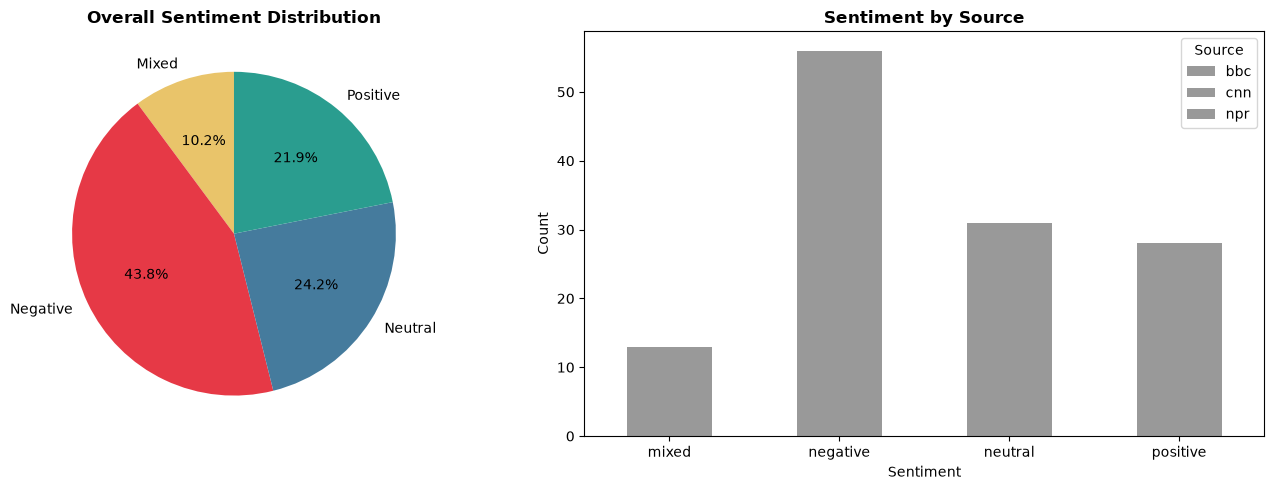

In [19]:
# Cell 5: 📊 Sentiment Distribution Chart
import matplotlib.pyplot as plt

df_sent = pd.read_sql_query(
    "SELECT ai_sentiment, source, COUNT(*) as cnt FROM articles "
    "WHERE ai_analyzed_at IS NOT NULL GROUP BY ai_sentiment, source",
    conn
)
pivot = df_sent.pivot(index="ai_sentiment", columns="source", values="cnt").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall pie
overall = df_sent.groupby("ai_sentiment")["cnt"].sum()
colors_pie = {"positive": "#2a9d8f", "negative": "#e63946", "neutral": "#457b9d", "mixed": "#e9c46a"}
pie_colors = [colors_pie.get(s, "#777") for s in overall.index]
axes[0].pie(overall.values, labels=overall.index.str.capitalize(), autopct="%1.1f%%",
            colors=pie_colors, startangle=90)
axes[0].set_title("Overall Sentiment Distribution", fontweight="bold")

# Stacked bar by source
pivot.plot(kind="bar", stacked=True, ax=axes[1],
           color=[colors_pie.get(c, "#999") for c in pivot.columns])
axes[1].set_title("Sentiment by Source", fontweight="bold")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")
axes[1].legend(title="Source")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

---
## 🏷️ Cell 6: Topic Frequency — What Themes is the AI Detecting?

Extracts all topic tags assigned by DeepSeek across all analyzed articles, normalizes them to lowercase, and plots the **top 20 most frequent topics** as a horizontal bar chart.

This gives you a high-level view of *what the news cycle is about* — e.g. "politics", "sports", "war", "economy", "technology" — directly from the AI's own categorization. More articles = more meaningful results.

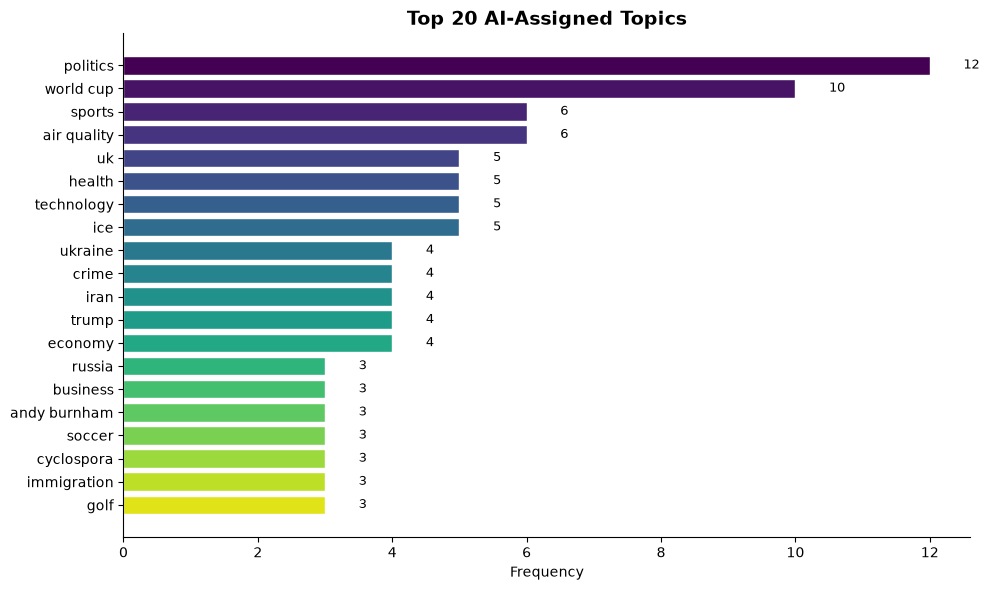

In [20]:
# Cell 6: 🏷️ Topic Frequency — What is the AI Seeing?
from collections import Counter

rows = conn.execute(
    "SELECT ai_topics FROM articles WHERE ai_analyzed_at IS NOT NULL AND ai_topics IS NOT NULL"
).fetchall()

topic_counter = Counter()
for (topics_str,) in rows:
    for t in topics_str.split(","):
        t = t.strip().lower()
        if t:
            topic_counter[t] += 1

top20 = topic_counter.most_common(20)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [t for t, c in top20]
counts = [c for t, c in top20]
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
ax.barh(labels, counts, color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 20 AI-Assigned Topics", fontsize=14, fontweight="bold")
for i, (t, c) in enumerate(top20):
    ax.text(c + 0.5, i, str(c), va="center", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

---
## 🔍 Cell 7: Deep-Dive Analysis — Single Article with Full Body Text

Picks the most recent unanalyzed article that has full body text (`has_body = 1`), and sends the **entire article** (up to 4000 chars) to DeepSeek for a detailed analysis. The AI returns a richer JSON with:

- **summary** — 2-3 sentence detailed summary
- **sentiment** — positive/negative/neutral/mixed
- **key_entities** — people, organizations, locations mentioned
- **main_themes** — 2-5 overarching themes
- **bias_assessment** — brief note on any perceived editorial slant

Results are both printed and saved to the DB. Use this for high-value articles where you want deeper insight.

In [ ]:
# Cell 7: 🔍 Deep-Dive — Analyze a Single Article with Full Body Text
import textwrap

# Pick the most recent article that has body text and hasn't been analyzed
row = conn.execute(
    "SELECT * FROM articles WHERE has_body = 1 AND ai_analyzed_at IS NULL "
    "ORDER BY first_seen_at DESC LIMIT 1"
).fetchone()

if row:
    print(f"📰 [{row['source'].upper()}] {row['title']}")
    print(f"📝 Body text length: {len(row['content'])} chars")
    print("─" * 70)

    prompt = (
        f"Article: {row['title']}\n\n"
        f"{row['content'][:4000]}\n\n"
        "Provide a detailed analysis in JSON with: summary (2-3 sentences), "
        "sentiment (positive/negative/neutral/mixed), key_entities (list of people/orgs/locations), "
        "main_themes (list of 2-5 themes), and bias_assessment (brief note on any perceived slant)."
    )

    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are an expert news analyst. Return ONLY valid JSON."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.3,
        max_tokens=1024,
        response_format={"type": "json_object"},
    )
    result = json.loads(resp.choices[0].message.content)

    # Display
    for key, val in result.items():
        print(f"\n📌 {key.replace('_', ' ').upper()}:")
        if isinstance(val, list):
            for item in val:
                print(f"   • {item}")
        else:
            print(textwrap.fill(str(val), width=100, initial_indent="   ", subsequent_indent="   "))

    # Save
    topics = ", ".join(result.get("main_themes", []))
    summary = result.get("summary", "")
    sentiment = result.get("sentiment", "neutral")
    now = datetime.now(timezone.utc).isoformat()
    conn.execute(
        "UPDATE articles SET ai_summary=?, ai_sentiment=?, ai_topics=?, ai_analyzed_at=? WHERE id=?",
        (summary, sentiment, topics, now, row["id"]),
    )
    conn.commit()
    print(f"\n💾 Saved to DB: [{sentiment}] {summary[:80]}…")
else:
    print("No unanalyzed articles with body text available. Try running fetch_news.py first, or run Cell 3.")


No unanalyzed articles with body text available. Try running fetch_news.py first, or run Cell 3.


: 